In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'Advertising.csv')
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [7]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [8]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


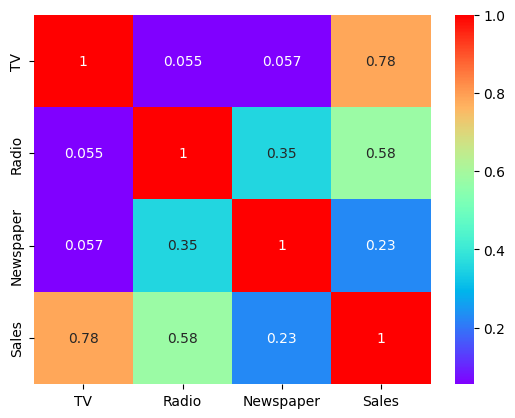

In [9]:
sns.heatmap(data=df.corr(),annot=True,cmap='rainbow')
plt.show()

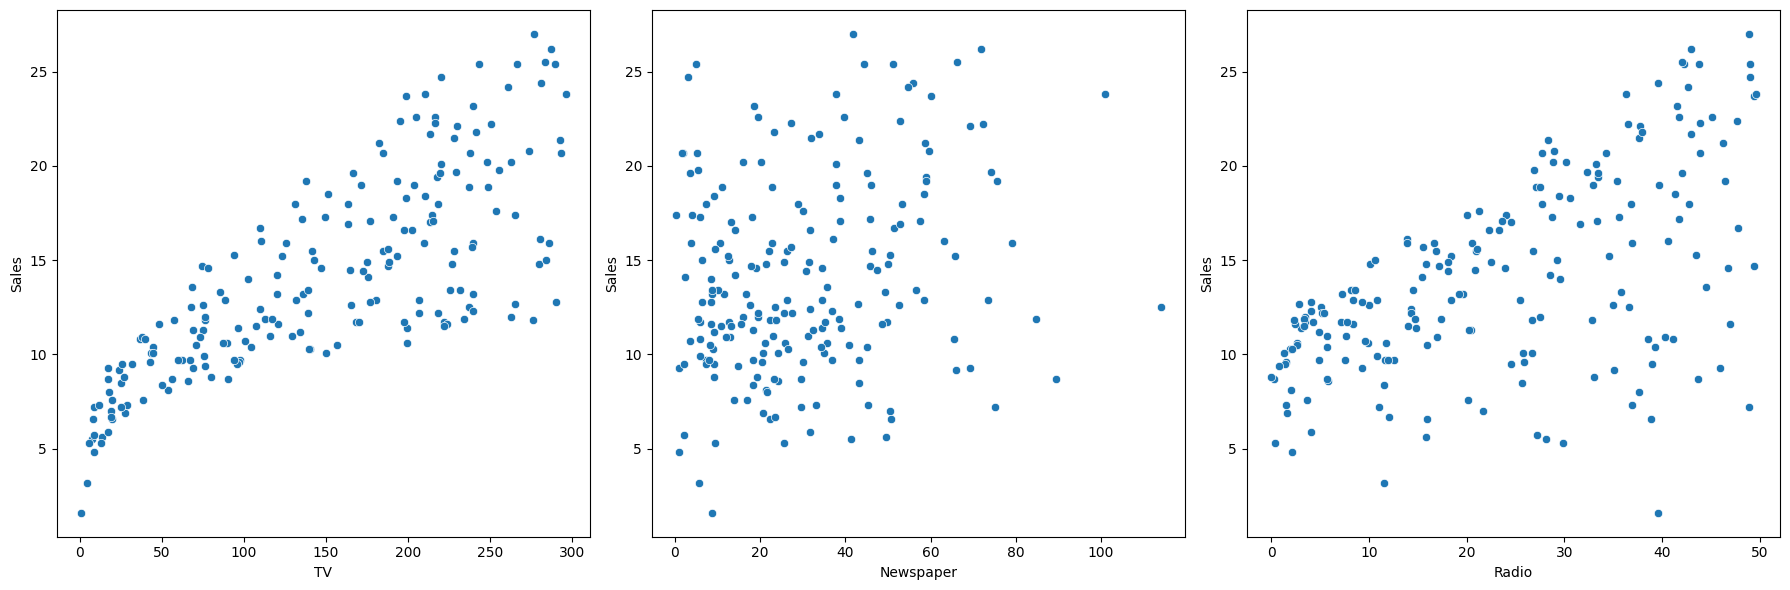

In [10]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
sns.scatterplot(x='TV',y='Sales',data=df)
plt.xlabel("TV")
plt.subplot(1,3,2)
sns.scatterplot(x='Newspaper',y='Sales',data=df)
plt.xlabel("Newspaper")
plt.subplot(1,3,3)
sns.scatterplot(x='Radio',y='Sales',data=df)
plt.xlabel("Radio")
plt.tight_layout()
plt.show()

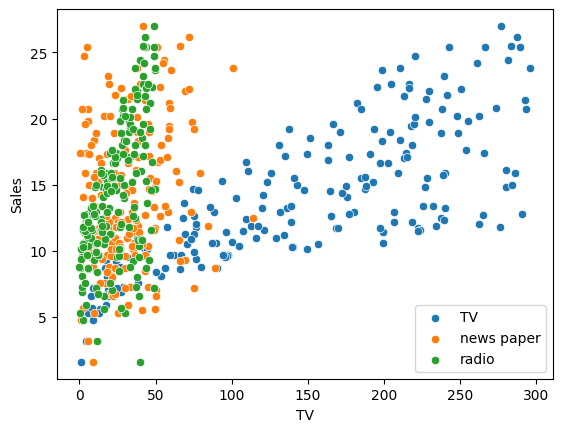

In [11]:
sns.scatterplot(x='TV',y='Sales',data=df,label='TV')
sns.scatterplot(x='Newspaper',y='Sales',data=df,label='news paper')
sns.scatterplot(x='Radio',y='Sales',data=df,label='radio')
plt.show()

In [12]:
X = df.iloc[:,:-1]
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [13]:
Y = df.iloc[:,-1]
Y.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,train_size=0.8,random_state=1)

In [16]:
print(f"Shape's:\nx_train - {x_train.shape}\nx_test -{x_test.shape}\ny_tarin - {y_train.shape}\ny_test - {y_test.shape}")

Shape's:
x_train - (160, 3)
x_test -(40, 3)
y_tarin - (160,)
y_test - (40,)


In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
lr = LinearRegression()

In [19]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
predicted = lr.predict(x_test)

In [21]:
predicted[:5]

array([21.73577184, 16.45693776,  7.65993185, 17.89202679, 18.67730671])

In [22]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(predicted,y_test)
print(f'MSE : {mse}')

MSE : 1.9918855518287906


In [23]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predicted)
print('R2 Score:', r2)

R2 Score: 0.8927605914615384


In [24]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})
coefficients

,Feature,Coefficient
0,TV,0.046843
1,Radio,0.178544
2,Newspaper,0.002586


In [25]:
print(lr.intercept_)

2.907947020816433


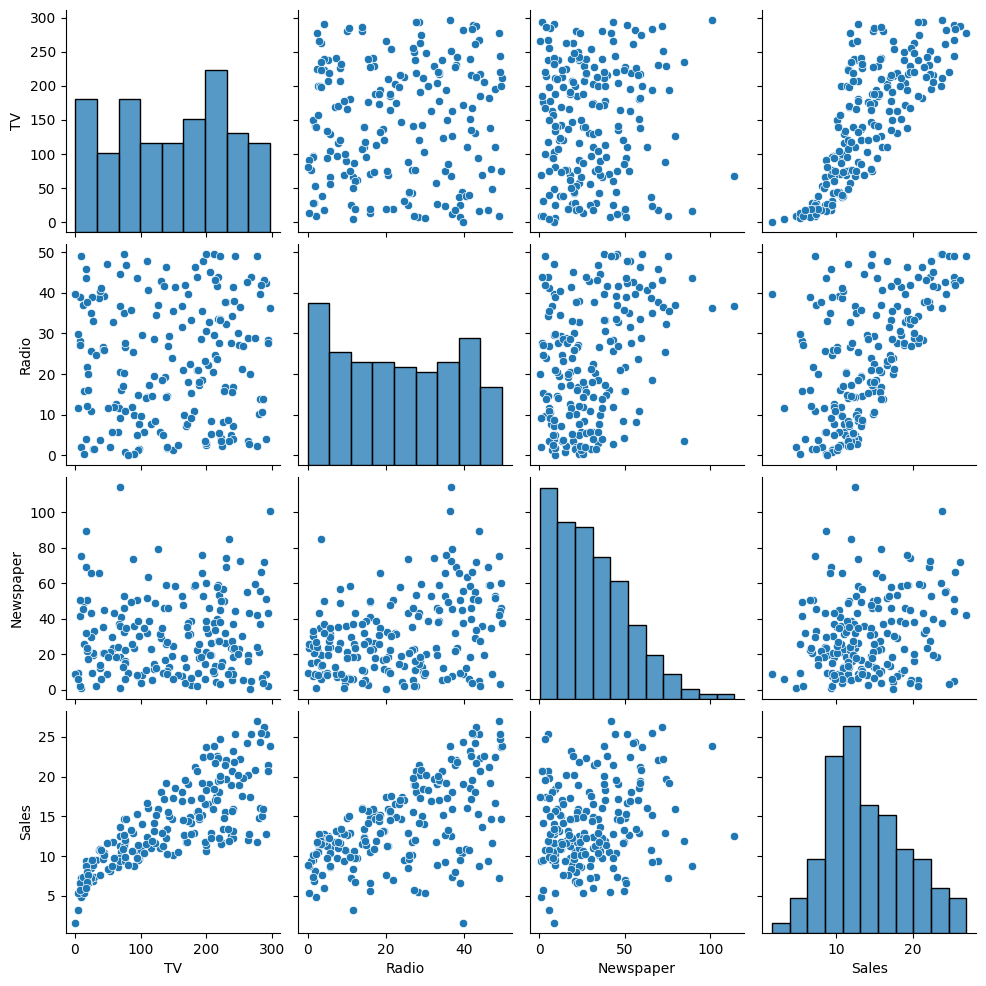

In [26]:
sns.pairplot(df)
plt.show()